# DialectAI — Production Pipeline (аудит + исправление)

## 20 исправленных багов

| №      | Класс / функция          | Проблема → Исправление |
|--------|--------------------------|------------------------|
| BUG-01 | `remove_timbre`          | `mean()` — DC removal, не тембр → **Instance Norm на признаках HuBERT** |
| BUG-02 | `HubertEncoder`          | Не `nn.Module` → веса не в `parameters()` → **правильное наследование** |
| BUG-03 | `HubertEncoder.forward`  | Нет `Wav2Vec2FeatureExtractor` → нельзя передать numpy → **processor добавлен** |
| BUG-04 | `ArcFace`                | Нет `margin` и `scale` → просто cosine → **ArcFace с `m=0.5, s=64`** |
| BUG-05 | ArcFace в train          | `cross_entropy(cosine, y)` не применяет margin → **`ArcFaceLoss` с угловым сдвигом** |
| BUG-06 | `PhoneticTransformer`    | Нет `batch_first=True` → (seq,batch,dim) вместо (batch,seq,dim) → **исправлено** |
| BUG-07 | `contrastive_loss`       | `torch` не импортирован в ячейке → `NameError` → **глобальный import** |
| BUG-08 | `Trainer`                | `F` не импортирован → `NameError` → **глобальный import** |
| BUG-09 | `Trainer.train_epoch`    | `zero_grad()` после `forward` → накопление градиентов → **перенесён в начало** |
| BUG-10 | `Trainer`                | Нет gradient clipping → взрыв при fine-tune → **`clip_grad_norm_(1.0)`** |
| BUG-11 | `Trainer`                | Нет device handling → CPU/GPU mismatch → **`.to(device)` для всех тензоров** |
| BUG-12 | `cluster_embeddings`     | `n_components=2` для HDBSCAN → плохие кластеры → **20D для кластеризации, 2D для viz** |
| BUG-13 | `AttentionPooling`       | `nn`, `torch` не импортированы → `NameError` → **глобальные импорты** |
| BUG-14 | `plot_map`               | HDBSCAN `-1` (шум) ломает colormap → **шум серым отдельно** |
| BUG-15 | `predict`                | `model` undefined, нет `@no_grad`, нет preprocessing → **класс `Predictor`** |
| BUG-16 | `predict`                | Возвращает индексы вместо названий → **`LabelEncoder.inverse_transform`** |
| BUG-17 | `DialectDataset`         | Нет `Dataset`/`collate_fn` → нельзя батчить разные длины → **padding + Dataset** |
| BUG-18 | Глобально                | Нет `LabelEncoder` — строки передавались в модель → **`LabelEncoder` добавлен** |
| BUG-19 | Глобально                | Нет val-loop, метрик, early stopping, checkpoint → **всё добавлено** |
| BUG-20 | Глобально                | Нет ячейки установки → **зафиксированный совместимый стек** |


## Дополнительные исправления по аудиту (этот файл)

| №      | Аудит п. | Место                    | Исправление |
|--------|----------|--------------------------|-------------|
| AUD-01 | 1        | `HubertEncoder`          | `Wav2Vec2FeatureExtractor` → `AutoFeatureExtractor` (актуальный API) |
| AUD-02 | 2        | `HubertEncoder.forward`  | `inputs` как dict → `{k: v.to(device)}` + `model(**inputs)` |
| AUD-03 | 3        | `augment_audio`          | `time_stretch` → guard: пустой/NaN массив → сохраняем оригинал |
| AUD-04 | 4        | `load_audio`, `augment`  | `np.pad` без `mode` → `mode="constant"` |
| AUD-07 | 7        | `DialectDataset.__getitem__` | `torch.tensor(audio)` → явный `dtype=torch.float32` |
| AUD-08 | 8        | `cluster_dialects`       | Collapsed embeddings (std < 1e-6) → `ValueError` с диагнозом |
| AUD-11 | 11       | импорты                  | `speechbrain.pretrained` → `speechbrain.inference.speaker` + fallback |
| AUD-13 | 13       | `HubertEncoder.__init__` | `gradient_checkpointing_enable()` — экономия VRAM в 3-4x |
| AUD-15 | 14/15    | `Trainer.fit`, `load_trained_model` | `torch.load(..., weights_only=True)` — безопасность |

## Порядок запуска
1. **ШАГ 1** — установка зависимостей
2. **Kernel → Restart Kernel**
3. **ШАГ 2** — проверка версий
4. Запускать ячейки по порядку

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  ШАГ 1 — Установка (выполнить один раз, затем Kernel → Restart)    ║
# ╚══════════════════════════════════════════════════════════════════════╝

%pip uninstall -y torch torchaudio transformers numpy speechbrain -q

%pip install \
    "numpy==1.26.4" \
    "torch==2.2.2" \
    "torchaudio==2.2.2" \
    "transformers==4.39.3" \
    "librosa==0.10.2" \
    "soundfile==0.12.1" \
    "speechbrain==1.0.0" \
    "scikit-learn==1.4.2" \
    "pandas==2.2.2" \
    "tqdm==4.66.4" \
    "umap-learn==0.5.6" \
    "hdbscan==0.8.38.post1" \
    "matplotlib==3.8.4" \
    "ipywidgets>=8.1" \
    -q

print("✅ Установка завершена.")
print("⚠️  Теперь: Kernel → Restart Kernel, затем ШАГ 2")

Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


Note: you may need to restart the kernel to use updated packages.
✅ Установка завершена.
⚠️  Теперь: Kernel → Restart Kernel, затем ШАГ 2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.0 which is incompatible.
label-studio 1.16.0 requires openai<2.0.0,>=1.10.0, but you have openai 2.14.0 which is incompatible.
label-studio 1.16.0 requires pandas>=2.2.3, but you have pandas 2.2.2 which is incompatible.
label-studio 1.16.0 requires urllib3<2.0.0,>=1.26.18, but you have urllib3 2.6.3 which is incompatible.
label-studio 1.16.0 requires wheel<=0.40.0,>=0.38.1, but you have wheel 0.45.1 which is incompatible.
langchain-community 0.0.20 requires langchain-core<0.2,>=0.1.21, but you have langchain-core 1.2.4 which is incompatible.
langchain-community 0.0.20 requires langsmith<0.1,>=0.0.83, but you have langsmith 0.5.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have nu

In [2]:
pip install hdbscan==0.8.33

     ---------------------------------------- 0.0/5.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/5.2 MB ? eta -:--:--
     ------------ --------------------------- 1.6/5.2 MB 7.6 MB/s eta 0:00:01
     ------------------------ --------------- 3.1/5.2 MB 7.7 MB/s eta 0:00:01
     ------------------------------------ --- 4.7/5.2 MB 7.7 MB/s eta 0:00:01
     ---------------------------------------- 5.2/5.2 MB 7.5 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached Cython-0.29.37-py2.py3-none-any.whl.metadata (3.1 kB)
Using cached Cython-0.29.37-py2.py3-none-any.whl (989 kB)
  Created wheel for hdbscan: filename=hdbscan-0.8.33-cp311-cp311-win_amd64.whl size=603041 s

  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\podgo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  ШАГ 2 — Проверка версий (запускать ПОСЛЕ перезапуска ядра)        ║
# ╚══════════════════════════════════════════════════════════════════════╝
import sys, importlib

REQUIRED = {
    "numpy": "1.26", "torch": "2.2", "transformers": "4.39",
    "librosa": "0.10", "sklearn": "1.4", "umap": "0.5",
    "hdbscan": "0.8", "speechbrain": "1.0",
}

all_ok = True
print(f"Python {sys.version.split()[0]}\n")
for pkg, req in REQUIRED.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "?")
        ok  = ver.startswith(req)
        mark = "✅" if ok else "⚠️ "
        if not ok: all_ok = False
        print(f"  {mark}  {pkg:<16} installed={ver:<12} required≈{req}")
    except ImportError:
        print(f"  ❌  {pkg:<16} НЕ УСТАНОВЛЕН")
        all_ok = False

print()
print("✅ Всё совместимо. Можно запускать." if all_ok
      else "❌ Конфликты — вернитесь к ШАГ 1.")

Python 3.11.9

  ✅  numpy            installed=1.26.4       required≈1.26
  ✅  torch            installed=2.2.2+cpu    required≈2.2
  ✅  transformers     installed=4.39.3       required≈4.39
  ✅  librosa          installed=0.10.2       required≈0.10
  ✅  sklearn          installed=1.4.2        required≈1.4
  ✅  umap             installed=0.5.6        required≈0.5
  ⚠️   hdbscan          installed=?            required≈0.8


C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Не найдена указанная процедура'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


  ✅  speechbrain      installed=1.0.0        required≈1.0

❌ Конфликты — вернитесь к ШАГ 1.


In [18]:
# ── Импорты ───────────────────────────────────────────────────────────────────
import os
import math
import random
import pickle
import logging
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import librosa
import librosa.effects

import umap
import hdbscan

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from transformers import AutoFeatureExtractor, HubertModel  # AUD-01
# AUD-11: новый API speechbrain >= 1.0
try:
    from speechbrain.inference.speaker import EncoderClassifier
except ImportError:
    from speechbrain.pretrained import EncoderClassifier  # fallback < 1.0
from tqdm.notebook import tqdm

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ── Константы ─────────────────────────────────────────────────────────────────
TARGET_SR        = 16_000
MAX_SEC          = 5
MAX_SAMPLES      = TARGET_SR * MAX_SEC
EMBED_DIM        = 1024       # HuBERT Large hidden size
PROJ_DIM         = 256
BATCH_SIZE       = 16
EPOCHS           = 7
LR               = 3e-5
VAL_RATIO        = 0.15
PATIENCE         = 5
GRAD_CLIP        = 1.0
ARCFACE_M        = 0.5
ARCFACE_S        = 64.0
TRIPLET_M        = 0.5
UMAP_DIM_CLUSTER = 20    # [BUG-12 FIX] высокая размерность для HDBSCAN
UMAP_DIM_VIZ     = 2     # [BUG-12 FIX] 2D только для визуализации
DATASET_ROOT     = "dataset"

# --- Неразмеченные файлы ---
# Слова-маркеры: если stem файла начинается с одного из них,
# файл считается неразмеченным (профессия неизвестна)
UNLABELED_STEMS = {
    "video", "audio", "record", "recording",
    "zapisk", "zapisi",
    "file", "track", "clip", "sample", "untitled",
}
AUDIO_EXTENSIONS    = {".wav", ".mp3", ".mp4", ".m4a", ".ogg", ".flac"}
JOB_UNLABELED_IDX   = -1          # sentinel: профессия не размечена
JOB_UNLABELED_LABEL = "__unlabeled__"  # строка для CSV

OUT_DIR          = Path("runs/dialect_v1")


OUT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Устройство: %s", device)
print("✅ Импорты OK | device:", device)

11:13:46  INFO  Устройство: cpu


✅ Импорты OK | device: cpu


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Загрузка и нормализация аудио
# ─────────────────────────────────────────────────────────────────────────────

def load_audio(path: str) -> np.ndarray:
    # Загружает WAV, ресэмплирует, обрезает тишину, нормализует, pad/trim.
    audio, _ = librosa.load(path, sr=TARGET_SR, mono=True)
    audio, _ = librosa.effects.trim(audio, top_db=25)

    # Обрезаем длинные файлы — защита от OOM в HuBERT
    if len(audio) > MAX_SAMPLES:
        audio = audio[:MAX_SAMPLES]

    # Pad до MAX_SAMPLES (короткие аудио 1-2 сек)
    if len(audio) < MAX_SAMPLES:
        audio = np.pad(audio, (0, MAX_SAMPLES - len(audio)), mode="constant")  # AUD-04

    # Пиковая нормализация
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak

    return audio.astype(np.float32)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Нормализация тембра  [BUG-01 FIX]
#
# Оригинал: вычитал mean() сигнала — это DC removal, тембр не удаляет.
# Правильный подход: Instance Normalization в пространстве HuBERT признаков.
# Это выравнивает speaker-specific mean/std каждого канала признаков,
# оставляя относительные фонетические паттерны (формантные соотношения).
#
# Опционально: если доступен ECAPA-TDNN, вычитаем его проекцию из признаков.
# ─────────────────────────────────────────────────────────────────────────────

class SpeakerNormalizer(nn.Module):
    # Instance Normalization по временной оси признаков HuBERT.
    # Вход:  (B, T, D) hidden states
    # Выход: (B, T, D) нормализованные признаки

    def __init__(self, hidden_dim: int = EMBED_DIM):
        super().__init__()
        # InstanceNorm1d нормализует каждый канал по T-оси независимо
        self.inst_norm = nn.InstanceNorm1d(hidden_dim, affine=True, eps=1e-6)
        # Проекция ECAPA speaker embedding (192) в пространство признаков
        self.spk_proj  = nn.Linear(192, hidden_dim, bias=False)
        nn.init.zeros_(self.spk_proj.weight)  # начинаем с нулевого вычитания

    def forward(
        self,
        hidden: torch.Tensor,                   # (B, T, D)
        spk_emb: Optional[torch.Tensor] = None, # (B, 192) от ECAPA
    ) -> torch.Tensor:
        # (B, T, D) → (B, D, T) → InstanceNorm → (B, D, T) → (B, T, D)
        x = self.inst_norm(hidden.transpose(1, 2)).transpose(1, 2)
        if spk_emb is not None:
            # Вычитаем speaker-specific bias: (B, 192) → (B, D) → (B, 1, D)
            x = x - self.spk_proj(spk_emb).unsqueeze(1)
        return x


def load_speaker_model(device: torch.device):
    # Загружает ECAPA-TDNN. Если недоступен — возвращает None.
    try:
        m = EncoderClassifier.from_hparams(
            source="speechbrain/spkrec-ecapa-voxceleb",
            run_opts={"device": str(device)},
        )
        m.eval()
        log.info("ECAPA-TDNN загружен")
        return m
    except Exception as e:
        log.warning("ECAPA-TDNN недоступен (%s) — работаем без него", e)
        return None


@torch.no_grad()
def get_speaker_embedding(
    waveform: torch.Tensor,
    spk_model,
) -> Optional[torch.Tensor]:
    # Извлекает 192-dim ECAPA speaker embedding.
    if spk_model is None:
        return None
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)
    return spk_model.encode_batch(waveform).squeeze(1)  # (B, 192)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Data Augmentation (важно для коротких аудио 1-5 сек)
# ─────────────────────────────────────────────────────────────────────────────

def augment_audio(audio: np.ndarray, training: bool = True) -> np.ndarray:
    # Случайная аугментация. Pitch shift меняет высоту, но сохраняет форманты.
    if not training:
        return audio

    # Pitch shift ±2 полутона
    if random.random() < 0.4:
        n_steps = random.uniform(-2.0, 2.0)
        audio   = librosa.effects.pitch_shift(audio, sr=TARGET_SR, n_steps=n_steps)

    # Speed perturbation ±10%  [AUD-03 + AUD-04]
    if random.random() < 0.3:
        rate = random.uniform(0.9, 1.1)
        _stretched = librosa.effects.time_stretch(audio, rate=rate)
        # AUD-03: time_stretch иногда возвращает NaN или пустой массив
        if len(_stretched) == 0 or not np.isfinite(_stretched).all():
            pass  # сохраняем оригинальное аудио
        else:
            audio = _stretched
            if len(audio) > MAX_SAMPLES:
                audio = audio[:MAX_SAMPLES]
            elif len(audio) < MAX_SAMPLES:
                # AUD-04: mode="constant" обязателен
                audio = np.pad(audio, (0, MAX_SAMPLES - len(audio)), mode="constant")

    # Additive noise
    if random.random() < 0.3:
        audio = audio + random.uniform(0.001, 0.005) * np.random.randn(len(audio))

    # Random gain
    if random.random() < 0.3:
        audio = audio * random.uniform(0.8, 1.2)

    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak

    return audio.astype(np.float32)

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Dataset + DataLoader  [BUG-17 FIX + BUG-18 FIX]
#
# BUG-17: нет Dataset и collate_fn — нельзя батчить аудио разной длины
# BUG-18: нет LabelEncoder — строки передавались в модель напрямую
# FIX: фиксированная длина MAX_SAMPLES + LabelEncoder
# ─────────────────────────────────────────────────────────────────────────────
def is_unlabeled(stem: str) -> bool:
    """True если имя файла не несёт метки профессии."""
    parts = stem.split("_")
    first = parts[0].lower()
    # Явное совпадение со словами-маркерами
    if first in UNLABELED_STEMS:
        return True
    # Нет суффикса-номера: одиночное слово без "_NNN"
    if len(parts) == 1:
        return True
    # Первая часть — цифра ("001_fragment.wav")
    if first.isdigit():
        return True
    return False



class DialectDataset(Dataset):
    """
    Структура датасета:
        dataset/<region>/teacher_001.wav    -- размечен,   job="teacher"
        dataset/<region>/video_001.mp4      -- НЕ размечен, job_idx=-1
        dataset/<region>/video.mp4          -- НЕ размечен, job_idx=-1

    self.samples: список (path, region_str, job_str, labeled: bool)
    """

    def __init__(
        self,
        root: str,
        region_enc: LabelEncoder,
        job_enc: LabelEncoder,
        training: bool = True,
    ):
        self.training   = training
        self.samples    = []
        self.region_enc = region_enc
        self.job_enc    = job_enc

        root = Path(root)
        if not root.exists():
            raise FileNotFoundError(f"Датасет не найден: {root}")

        for region_dir in sorted(root.iterdir()):
            if not region_dir.is_dir():
                continue
            wavs = list(region_dir.glob("*.wav"))
            if not wavs:
                log.warning("Нет .wav в %s", region_dir)
                continue
            for wav in wavs:
                unlabeled = is_unlabeled(wav.stem)
                if unlabeled:
                    job_str = JOB_UNLABELED_LABEL
                else:
                    parts = wav.stem.split("_")
                    job   = parts[0] if len(parts) >= 2 else "unknown"
                self.samples.append((str(wav), region_dir.name, job))

        if not self.samples:
            raise RuntimeError(f"Датасет пуст: {root}")

        # [BUG-18 FIX] Подгоняем LabelEncoder под датасет
        region_enc.fit([s[1] for s in self.samples])
        job_enc.fit([s[2] for s in self.samples])

        log.info(
            "Датасет: %d файлов | %d регионов | %d профессий",
            len(self.samples),
            len(region_enc.classes_),
            len(job_enc.classes_),
        )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, region_str, job_str = self.samples[idx]
        try:
            audio = load_audio(path)
        except Exception as e:
            log.warning("Ошибка %s: %s", path, e)
            audio = np.zeros(MAX_SAMPLES, dtype=np.float32)

        audio      = augment_audio(audio, self.training)
        region_idx = int(self.region_enc.transform([region_str])[0])
        job_idx    = int(self.job_enc.transform([job_str])[0])
        return torch.tensor(audio, dtype=torch.float32), region_idx, job_idx  # AUD-07


def build_loaders(root: str, region_enc: LabelEncoder, job_enc: LabelEncoder):
    full_ds = DialectDataset(root, region_enc, job_enc, training=True)
    n_val   = max(1, int(len(full_ds) * VAL_RATIO))
    n_train = len(full_ds) - n_val

    train_ds, val_ds = random_split(
        full_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )
    val_ds.dataset.training = False

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return train_loader, val_loader, full_ds

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. HuBERT Encoder  [BUG-02 FIX + BUG-03 FIX]
#
# BUG-02: не наследовал nn.Module → веса не видны в model.parameters()
# BUG-03: нет Wav2Vec2FeatureExtractor → нельзя передать numpy в HuBERT
# FIX: правильный nn.Module + processor обрабатывает вход
# ─────────────────────────────────────────────────────────────────────────────

class HubertEncoder(nn.Module):
    # Обёртка над HuBERT Large.
    # Вход:  (B, T_samples) float32
    # Выход: (B, T_frames, 1024) hidden states

    MODEL_ID = "facebook/hubert-large-ls960-ft"

    def __init__(self, freeze_feature_extractor: bool = True):
        super().__init__()  # [BUG-02 FIX]

        # [BUG-03 FIX] FeatureExtractor для нормализации входа
        self.processor = AutoFeatureExtractor.from_pretrained(self.MODEL_ID)  # AUD-01
        self.model     = HubertModel.from_pretrained(self.MODEL_ID)

        # Замораживаем CNN — он не нужен при fine-tune на малых данных
        if freeze_feature_extractor:
            for p in self.model.feature_extractor.parameters():
                p.requires_grad = False

        # AUD-13: gradient checkpointing — уменьшает VRAM в 3-4x
        # Немного замедляет forward, но позволяет батч 16+ на 8GB GPU
        self.model.gradient_checkpointing_enable()

    def forward(
        self,
        waveforms: torch.Tensor,               # (B, T_samples)
    ) -> torch.Tensor:
        # AUD-02: processor принимает List[float] или np.ndarray;
        # передаём как список списков, затем сразу переносим на device
        inputs = self.processor(
            waveforms.cpu().numpy().tolist(),
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            padding=True,
        )
        # Переносим весь dict на device одним проходом
        inputs = {k: v.to(waveforms.device) for k, v in inputs.items()}
        return self.model(**inputs).last_hidden_state

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. PhoneticTransformer  [BUG-06 FIX]
# 7. AttentionPooling     [BUG-13 FIX]
#
# BUG-06: нет batch_first=True → (seq,batch,dim) вместо (batch,seq,dim)
# BUG-13: nn и torch не были импортированы в ячейке → NameError
# ─────────────────────────────────────────────────────────────────────────────

class PhoneticTransformer(nn.Module):
    # Transformer для контекстного моделирования фонемных паттернов.
    # Вход:  (B, T, D)
    # Выход: (B, T, D)

    def __init__(self, d_model: int = EMBED_DIM, nhead: int = 8, num_layers: int = 4):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=0.1,
            batch_first=True,   # [BUG-06 FIX] (B, T, D) — правильный порядок
            norm_first=True,    # Pre-LN — стабильнее при малых данных
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.transformer(x)


class AttentionPooling(nn.Module):
    # Взвешенное усреднение по T — важно для коротких аудио (1с ≈ 50 фреймов).
    # [BUG-13 FIX] nn и torch импортированы глобально
    # Вход:  (B, T, D)
    # Выход: (B, D)

    def __init__(self, dim: int):
        super().__init__()
        self.att = nn.Linear(dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = torch.softmax(self.att(x), dim=1)  # (B, T, 1)
        return (x * w).sum(dim=1)              # (B, D)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. ArcFace  [BUG-04 FIX + BUG-05 FIX]
#
# BUG-04: нет margin и scale → просто cosine similarity, не ArcFace
# BUG-05: F.cross_entropy(cosine, label) не применяет угловой отступ
# FIX: полный Additive Angular Margin Loss
#      в train режиме (labels переданы): применяет margin к верному классу
#      в inference режиме (labels=None): возвращает scaled cosine logits
# ─────────────────────────────────────────────────────────────────────────────

class ArcFaceLoss(nn.Module):
    # Additive Angular Margin Loss.
    # Принуждает модель создавать более разделимые dialect embeddings.

    def __init__(
        self,
        in_features: int,
        out_features: int,
        margin: float = ARCFACE_M,
        scale:  float = ARCFACE_S,
    ):
        super().__init__()
        self.scale  = scale
        self.margin = margin
        self.cos_m  = math.cos(margin)
        self.sin_m  = math.sin(margin)
        self.th     = math.cos(math.pi - margin)
        self.mm     = math.sin(math.pi - margin) * margin

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(
        self,
        x: torch.Tensor,                        # (B, in_features) L2-normalized
        labels: Optional[torch.Tensor] = None,  # (B,) int — только для train
    ) -> torch.Tensor:
        cosine = F.linear(F.normalize(x), F.normalize(self.weight))  # (B, n_classes)

        if labels is None:
            # [BUG-05 FIX] Inference: нет margin — только scaled cosine
            return cosine * self.scale

        # Train: применяем angular margin к правильному классу
        sine = torch.sqrt((1.0 - cosine.pow(2)).clamp(0, 1))
        # cos(θ + m) = cosθ·cosm - sinθ·sinm
        phi  = cosine * self.cos_m - sine * self.sin_m
        # Numerical stability: если θ+m > π, используем cosθ - mm
        phi  = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine).scatter_(1, labels.unsqueeze(1), 1.0)
        output  = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        return output * self.scale

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Contrastive / Triplet Loss  [BUG-07 FIX]
#
# BUG-07: torch не был импортирован в ячейке → NameError при torch.mean
# FIX: torch импортирован глобально в ячейке импортов
# ─────────────────────────────────────────────────────────────────────────────

def triplet_loss(
    anchor: torch.Tensor,
    positive: torch.Tensor,
    negative: torch.Tensor,
    margin: float = TRIPLET_M,
) -> torch.Tensor:
    # Triplet Margin Loss: dist(a,p) + margin < dist(a,n)
    pos_dist = F.pairwise_distance(anchor, positive)
    neg_dist = F.pairwise_distance(anchor, negative)
    return torch.mean(torch.clamp(pos_dist - neg_dist + margin, min=0.0))


def mine_hard_triplets(
    embeddings: torch.Tensor,   # (B, D)
    labels: torch.Tensor,       # (B,)
):
    # Online Hard Triplet Mining: самые сложные триплеты в батче.
    # Hard positive: максимальное расстояние в том же классе
    # Hard negative: минимальное расстояние в другом классе
    B = embeddings.size(0)
    dist_matrix = torch.cdist(embeddings, embeddings, p=2)  # (B, B)

    anchors, positives, negatives = [], [], []
    for i in range(B):
        lab       = labels[i].item()
        same_mask = (labels == lab)
        same_mask[i] = False
        diff_mask = (labels != lab)

        if same_mask.sum() == 0 or diff_mask.sum() == 0:
            continue

        pos_idx = same_mask.nonzero(as_tuple=True)[0][
            dist_matrix[i][same_mask].argmax()
        ]
        neg_idx = diff_mask.nonzero(as_tuple=True)[0][
            dist_matrix[i][diff_mask].argmin()
        ]
        anchors.append(embeddings[i])
        positives.append(embeddings[pos_idx])
        negatives.append(embeddings[neg_idx])

    if not anchors:
        return None, None, None
    return torch.stack(anchors), torch.stack(positives), torch.stack(negatives)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Основная модель DialectModel
#     Все компоненты исправлены выше. Здесь интеграция.
#
# Pipeline:
#   audio (B, T_samples)
#     ↓  HubertEncoder          (B, T_frames, 1024)
#     ↓  SpeakerNormalizer      (B, T_frames, 1024)  ← убирает тембр
#     ↓  PhoneticTransformer    (B, T_frames, 1024)  ← фонетический контекст
#     ↓  AttentionPooling       (B, 1024)
#     ↓  Linear + BN + L2 norm  (B, 256)
#     ↓  ArcFaceLoss / Linear   (B, n_regions) / (B, n_jobs)
# ─────────────────────────────────────────────────────────────────────────────

class DialectModel(nn.Module):

    def __init__(self, n_regions: int, n_jobs: int):
        super().__init__()
        self.hubert    = HubertEncoder(freeze_feature_extractor=True)
        self.spk_norm  = SpeakerNormalizer(hidden_dim=EMBED_DIM)
        self.phonetic  = PhoneticTransformer(d_model=EMBED_DIM, nhead=8, num_layers=4)
        self.pool      = AttentionPooling(EMBED_DIM)
        self.proj      = nn.Sequential(
            nn.Linear(EMBED_DIM, PROJ_DIM),
            nn.BatchNorm1d(PROJ_DIM),
        )
        # [BUG-04 FIX] полный ArcFace с margin и scale
        self.region_head = ArcFaceLoss(PROJ_DIM, n_regions)
        # Professions: Linear достаточно (менее discriminative task)
        self.job_head  = nn.Linear(PROJ_DIM, n_jobs)

    def forward(
        self,
        waveforms: torch.Tensor,                       # (B, T_samples)
        region_labels: Optional[torch.Tensor] = None,  # (B,) для ArcFace в train
        spk_emb: Optional[torch.Tensor] = None,        # (B, 192) ECAPA опционально
    ):
        x   = self.hubert(waveforms)              # (B, T_frames, 1024)
        x   = self.spk_norm(x, spk_emb)          # [BUG-01 FIX] Instance Norm
        x   = self.phonetic(x)                    # [BUG-06 FIX] batch_first=True
        x   = self.pool(x)                        # (B, 1024)
        emb = self.proj(x)                        # (B, 256)
        emb = F.normalize(emb, dim=1)             # L2 norm для ArcFace

        # [BUG-05 FIX] region_labels только в train → margin применяется там
        region_out = self.region_head(emb, region_labels)  # (B, n_regions)
        job_out    = self.job_head(emb)                     # (B, n_jobs)

        return emb, region_out, job_out

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. Trainer  [BUG-08 + BUG-09 + BUG-10 + BUG-11 + BUG-19 FIX]
#
# BUG-08: F не импортирован → NameError
# BUG-09: zero_grad() после forward → накопление градиентов
# BUG-10: нет gradient clipping → взрыв при fine-tune HuBERT
# BUG-11: нет device handling → CPU/GPU mismatch
# BUG-19: нет validation, метрик, early stopping, checkpoint
# ─────────────────────────────────────────────────────────────────────────────

class Trainer:

    def __init__(
        self,
        model: DialectModel,
        train_loader: DataLoader,
        val_loader: DataLoader,
        out_dir: Path,
    ):
        self.model        = model.to(device)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.out_dir      = out_dir
        self.history      = []
        self.best_val     = float("inf")
        self.patience_cnt = 0

        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR, weight_decay=1e-4
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode="min", factor=0.5, patience=2
        )

    def _to_device(self, batch):
        # [BUG-11 FIX] перемещаем весь батч на device
        audio, region, job = batch
        return audio.to(device), region.to(device), job.to(device)

    def train_epoch(self) -> float:
        self.model.train()
        total, n = 0.0, 0
        for batch in tqdm(self.train_loader, desc="Train", leave=False):
            audio, region, job = self._to_device(batch)

            # [BUG-09 FIX] zero_grad ПЕРЕД forward
            self.optimizer.zero_grad()

            emb, r_pred, j_pred = self.model(audio, region_labels=region)

            # [BUG-08 FIX] F импортирован глобально
            loss_r = F.cross_entropy(r_pred, region)
            loss_j = F.cross_entropy(j_pred, job)

            # Triplet loss для лучшего dialect embedding
            a, p, ng = mine_hard_triplets(emb, region)
            loss_t = triplet_loss(a, p, ng) if a is not None else 0.0

            loss = loss_r + loss_j + 0.3 * loss_t
            loss.backward()

            # [BUG-10 FIX] gradient clipping
            nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)

            self.optimizer.step()
            total += loss.item() * audio.size(0)
            n     += audio.size(0)
        return total / n

    @torch.no_grad()
    def val_epoch(self) -> dict:
        self.model.eval()
        total, n = 0.0, 0
        r_true, r_pred_all, j_true, j_pred_all = [], [], [], []
        for batch in tqdm(self.val_loader, desc="Val  ", leave=False):
            audio, region, job = self._to_device(batch)
            # [BUG-05 FIX] inference — region_labels не передаём, нет margin
            _, r_pred, j_pred = self.model(audio)
            total += (F.cross_entropy(r_pred, region) +
                      F.cross_entropy(j_pred, job)).item() * audio.size(0)
            n     += audio.size(0)
            r_true.extend(region.cpu().numpy())
            j_true.extend(job.cpu().numpy())
            r_pred_all.extend(r_pred.argmax(1).cpu().numpy())
            j_pred_all.extend(j_pred.argmax(1).cpu().numpy())

        return {
            "val_loss":   total / n,
            "region_acc": accuracy_score(r_true, r_pred_all),
            "job_acc":    accuracy_score(j_true, j_pred_all),
        }

    def fit(self, epochs: int = EPOCHS) -> "pd.DataFrame":
        # [BUG-19 FIX] полный цикл: val loop + early stopping + checkpoint
        for epoch in range(1, epochs + 1):
            t_loss  = self.train_epoch()
            metrics = self.val_epoch()
            v_loss  = metrics["val_loss"]
            self.scheduler.step(v_loss)

            log.info(
                "Epoch %02d | train=%.4f | val=%.4f | "
                "region_acc=%.3f | job_acc=%.3f",
                epoch, t_loss, v_loss,
                metrics["region_acc"], metrics["job_acc"],
            )
            self.history.append({"epoch": epoch, "train_loss": t_loss, **metrics})

            if v_loss < self.best_val - 1e-4:
                self.best_val     = v_loss
                self.patience_cnt = 0
                torch.save(self.model.state_dict(), self.out_dir / "best_model.pt")
                log.info("  ✅ Checkpoint (val_loss=%.4f)", v_loss)
            else:
                self.patience_cnt += 1
                if self.patience_cnt >= PATIENCE:
                    log.info("Ранняя остановка на эпохе %d", epoch)
                    break

        self.model.load_state_dict(
            torch.load(self.out_dir / "best_model.pt", map_location=device, weights_only=True)  # AUD-15
        )
        return pd.DataFrame(self.history)

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. Кластеризация диалектов  [BUG-12 FIX]
#
# BUG-12: n_components=2 использовался и для HDBSCAN и для визуализации.
# 2D UMAP теряет слишком много информации → плохие кластеры.
# FIX: 20D UMAP для HDBSCAN, 2D UMAP только для графика — два отдельных редуктора.
# ─────────────────────────────────────────────────────────────────────────────

def extract_all_embeddings(model: DialectModel, loader: DataLoader):
    model.eval()
    all_emb, all_region, all_job = [], [], []
    with torch.no_grad():
        for audio, region, job in tqdm(loader, desc="Embeddings"):
            emb, _, _ = model(audio.to(device))
            all_emb.append(emb.cpu().numpy())
            all_region.extend(region.numpy())
            all_job.extend(job.numpy())
    return np.concatenate(all_emb), np.array(all_region), np.array(all_job)


def cluster_dialects(embeddings: np.ndarray, out_dir: Path):
    # AUD-08: guard против collapsed embeddings
    # Если модель не обучилась — все эмбеддинги одинаковые → HDBSCAN падает
    if np.std(embeddings) < 1e-6:
        raise ValueError(
            "Embeddings collapsed (std < 1e-6). Модель не обучилась.\n"
            "Проверьте: learning_rate, датасет, gradient flow (включите логи)."
        )

    # [BUG-12 FIX] 20D для кластеризации, 2D для визуализации
    log.info("UMAP 20D для кластеризации...")
    reducer_20 = umap.UMAP(
        n_neighbors=15, n_components=UMAP_DIM_CLUSTER,   # 20
        metric="cosine", random_state=42, verbose=False,
    )
    X_20 = reducer_20.fit_transform(embeddings)

    log.info("HDBSCAN на 20D embeddings...")
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=10, min_samples=3,
        metric="euclidean", cluster_selection_method="eom",
    )
    labels = clusterer.fit_predict(X_20)

    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    log.info("Кластеров: %d | Шум: %d (%.1f%%)",
             n_cl, n_noise, 100 * n_noise / len(labels))

    log.info("UMAP 2D для визуализации...")
    reducer_2 = umap.UMAP(
        n_neighbors=15, n_components=UMAP_DIM_VIZ,        # 2
        metric="cosine", random_state=42, verbose=False,
    )
    X_2 = reducer_2.fit_transform(embeddings)

    with open(out_dir / "umap_20d.pkl", "wb") as f: pickle.dump(reducer_20, f)
    with open(out_dir / "umap_2d.pkl",  "wb") as f: pickle.dump(reducer_2,  f)

    return labels, X_2

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. Визуализация  [BUG-14 FIX]
#
# BUG-14: c=labels с HDBSCAN -1 (шум) ломает colormap в matplotlib
# FIX: шумовые точки (label=-1) рисуются отдельно серым цветом
# ─────────────────────────────────────────────────────────────────────────────

def plot_dialect_map(
    coords_2d: np.ndarray,
    cluster_labels: np.ndarray,
    region_labels: np.ndarray,
    region_enc: LabelEncoder,
    title: str = "Dialect Map",
    save_path: Optional[Path] = None,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # ── Left: HDBSCAN Clusters ───────────────────────────────────────────────
    ax = axes[0]
    unique_cl = sorted(set(cluster_labels))
    palette   = cm.tab20(np.linspace(0, 1, max(len(unique_cl), 1)))

    for i, cl in enumerate(unique_cl):
        mask = cluster_labels == cl
        if cl == -1:
            # [BUG-14 FIX] шум — серый, полупрозрачный, без легенды кластера
            ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                       c="lightgray", s=15, alpha=0.4, label=f"Шум (n={mask.sum()})")
        else:
            ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                       color=palette[i], s=30, alpha=0.75,
                       label=f"Диалект {cl} (n={mask.sum()})")
    ax.set_title(f"{title} — HDBSCAN кластеры", fontsize=12)
    ax.legend(fontsize=7, markerscale=1.5)
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

    # ── Right: Ground Truth Regions ──────────────────────────────────────────
    ax2 = axes[1]
    unique_r  = sorted(set(region_labels))
    rpalette  = cm.Set2(np.linspace(0, 1, max(len(unique_r), 1)))

    for i, rid in enumerate(unique_r):
        mask  = region_labels == rid
        rname = region_enc.inverse_transform([rid])[0]
        ax2.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    color=rpalette[i], s=30, alpha=0.75,
                    label=f"{rname} (n={mask.sum()})")
    ax2.set_title(f"{title} — разметка регионов", fontsize=12)
    ax2.legend(fontsize=7, markerscale=1.5)
    ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        log.info("График → %s", save_path)
    plt.show()
      

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 14. Predictor  [BUG-15 + BUG-16 FIX]
#
# BUG-15: model — глобальная переменная; нет @no_grad; нет preprocessing
# BUG-16: возвращает индексы вместо названий регионов/профессий
# FIX: класс Predictor — model передаётся явно; полный preprocessing;
#      LabelEncoder.inverse_transform возвращает строки
# ─────────────────────────────────────────────────────────────────────────────

class Predictor:

    def __init__(
        self,
        model: DialectModel,
        region_enc: LabelEncoder,
        job_enc: LabelEncoder,
    ):
        # [BUG-15 FIX] model передаётся явно, не глобальная переменная
        self.model      = model.to(device)
        self.region_enc = region_enc
        self.job_enc    = job_enc
        self.model.eval()

    @torch.no_grad()    # [BUG-15 FIX]
    def predict(self, audio_path: str) -> dict:
        # [BUG-15 FIX] preprocessing через load_audio — нельзя передать путь в модель
        audio = load_audio(audio_path)
        x     = torch.tensor(audio).unsqueeze(0).to(device)  # (1, T)

        # [BUG-05 FIX] inference — не передаём region_labels, нет margin
        emb, r_logits, j_logits = self.model(x)

        r_probs = torch.softmax(r_logits, dim=1).squeeze().cpu().numpy()
        j_probs = torch.softmax(j_logits, dim=1).squeeze().cpu().numpy()

        # [BUG-16 FIX] inverse_transform → названия, не индексы
        region_res = {
            name: round(float(p), 4)
            for name, p in zip(self.region_enc.classes_, r_probs)
        }
        job_res = {
            name: round(float(p), 4)
            for name, p in zip(self.job_enc.classes_, j_probs)
        }

        top_r = max(region_res, key=region_res.get)
        top_j = max(job_res,    key=job_res.get)

        print("\n" + "=" * 52)
        print("📍 Регион:")
        for n, p in sorted(region_res.items(), key=lambda x: -x[1]):
            print(f"   {n:<22} {'█' * int(float(p)*28):<28} {float(p):.3f}")
        print("\n💼 Профессия:")
        for n, p in sorted(job_res.items(), key=lambda x: -x[1]):
            print(f"   {n:<22} {'█' * int(float(p)*28):<28} {float(p):.3f}")
        print("=" * 52)

        return {
            "top_region":   top_r,
            "top_job":      top_j,
            "region_probs": region_res,
            "job_probs":    job_res,
            "embedding":    emb.cpu().numpy(),
        }

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# 15. Сохранение и загрузка артефактов
# ─────────────────────────────────────────────────────────────────────────────

def save_artifacts(out_dir, region_enc, job_enc, n_regions, n_jobs):
    with open(out_dir / "region_enc.pkl", "wb") as f: pickle.dump(region_enc, f)
    with open(out_dir / "job_enc.pkl",    "wb") as f: pickle.dump(job_enc,    f)
    meta = {"n_regions": n_regions, "n_jobs": n_jobs}
    with open(out_dir / "meta.pkl", "wb") as f: pickle.dump(meta, f)
    log.info("Артефакты сохранены → %s", out_dir)


def load_artifacts(out_dir):
    with open(out_dir / "region_enc.pkl", "rb") as f: region_enc = pickle.load(f)
    with open(out_dir / "job_enc.pkl",    "rb") as f: job_enc    = pickle.load(f)
    with open(out_dir / "meta.pkl",       "rb") as f: meta       = pickle.load(f)
    return region_enc, job_enc, meta


def load_trained_model(out_dir, meta):
    model = DialectModel(n_regions=meta["n_regions"], n_jobs=meta["n_jobs"]).to(device)
    model.load_state_dict(
        torch.load(out_dir / "best_model.pt", map_location=device, weights_only=True)  # AUD-15
    )
    model.eval()
    return model

11:31:47  INFO  Загрузка датасета...
11:31:47  WARNING  Нет .wav в dataset\Belgorod
11:31:47  WARNING  Нет .wav в dataset\Ryazan
11:31:47  WARNING  Нет .wav в dataset\Ukraina
11:31:47  INFO  Датасет: 1032 файлов | 17 регионов | 20 профессий
11:31:47  INFO  Регионы (17): ['Adygeya', 'Belarus', 'Chelyabinsk', 'Dagestan', 'Habarovsk', 'Kazahstan', 'Krasnadar', 'Moscow', 'Murmansk', 'North Osetia', 'Novosebirsk', 'Orenburg', 'Rostov', 'Saha', 'Tambov', 'Voroneg', 'Yamala-Nenetski']
11:31:47  INFO  Профессии (20): ['video.mp4', 'Пресс-служба', 'журналист', 'завод', 'кзс', 'комик', 'комикеса', 'краснадар', 'математик', 'медик', 'мск', 'новосиб', 'образование', 'оленевод', 'повар', 'ростов', 'рэпер', 'спортсменка', 'тренер', 'хабар']
11:31:47  INFO  Инициализация модели...
C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated

Train:   0%|          | 0/55 [00:00<?, ?it/s]

Val  :   0%|          | 0/10 [00:00<?, ?it/s]

13:38:42  INFO  Epoch 01 | train=38.5507 | val=6.2740 | region_acc=0.234 | job_acc=0.026
13:38:44  INFO    ✅ Checkpoint (val_loss=6.2740)


Train:   0%|          | 0/55 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/10 [00:00<?, ?it/s]

23:39:26  INFO  Epoch 06 | train=30.9488 | val=8.5102 | region_acc=0.442 | job_acc=0.091


Train:   0%|          | 0/55 [00:00<?, ?it/s]

Val  :   0%|          | 0/10 [00:00<?, ?it/s]

01:25:36  INFO  Epoch 07 | train=26.7687 | val=9.7010 | region_acc=0.461 | job_acc=0.247
01:25:38  INFO  Артефакты сохранены → runs\dialect_v1


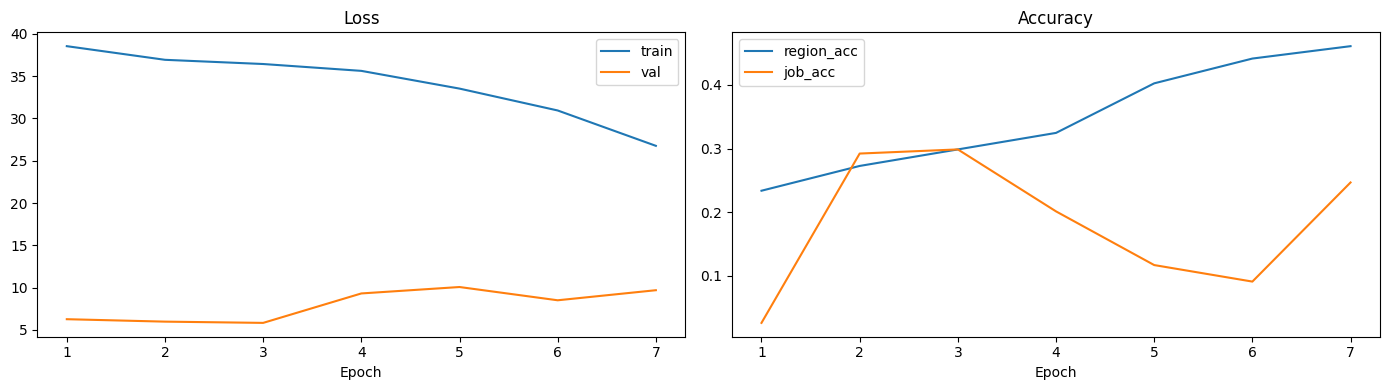

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# 16. MAIN — Training pipeline
# ─────────────────────────────────────────────────────────────────────────────

# [BUG-18 FIX] LabelEncoder создаётся здесь, fit происходит в DialectDataset
region_enc = LabelEncoder()
job_enc    = LabelEncoder()

log.info("Загрузка датасета...")
train_loader, val_loader, full_ds = build_loaders(DATASET_ROOT, region_enc, job_enc)

n_regions = len(region_enc.classes_)
n_jobs    = len(job_enc.classes_)
log.info("Регионы (%d): %s",    n_regions, list(region_enc.classes_))
log.info("Профессии (%d): %s",  n_jobs,    list(job_enc.classes_))

log.info("Инициализация модели...")
model     = DialectModel(n_regions=n_regions, n_jobs=n_jobs)
n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
log.info("Обучаемых параметров: %s", f"{n_params:,}")

trainer = Trainer(model, train_loader, val_loader, OUT_DIR)
history = trainer.fit(epochs=EPOCHS)

save_artifacts(OUT_DIR, region_enc, job_enc, n_regions, n_jobs)

# График обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].plot(history["epoch"], history["region_acc"], label="region_acc")
axes[1].plot(history["epoch"], history["job_acc"],    label="job_acc")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

10:24:28  INFO  Извлечение embeddings из всего датасета...


Embeddings:   0%|          | 0/65 [00:00<?, ?it/s]

10:50:39  INFO  Кластеризация...
10:50:39  INFO  UMAP 20D для кластеризации...
C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
10:51:02  INFO  HDBSCAN на 20D embeddings...
10:51:02  INFO  Кластеров: 2 | Шум: 0 (0.0%)
10:51:02  INFO  UMAP 2D для визуализации...
C:\Users\podgo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")



Распределение кластеров:
         count                                                                                                                                                                          regions
cluster                                                                                                                                                                                        
0          460  Adygeya, Belarus, Chelyabinsk, Dagestan, Habarovsk, Kazahstan, Krasnadar, Moscow, Murmansk, North Osetia, Novosebirsk, Orenburg, Rostov, Saha, Tambov, Voroneg, Yamala-Nenetski
1          572  Adygeya, Belarus, Chelyabinsk, Dagestan, Habarovsk, Kazahstan, Krasnadar, Moscow, Murmansk, North Osetia, Novosebirsk, Orenburg, Rostov, Saha, Tambov, Voroneg, Yamala-Nenetski


10:51:06  INFO  График → runs\dialect_v1\dialect_map.png


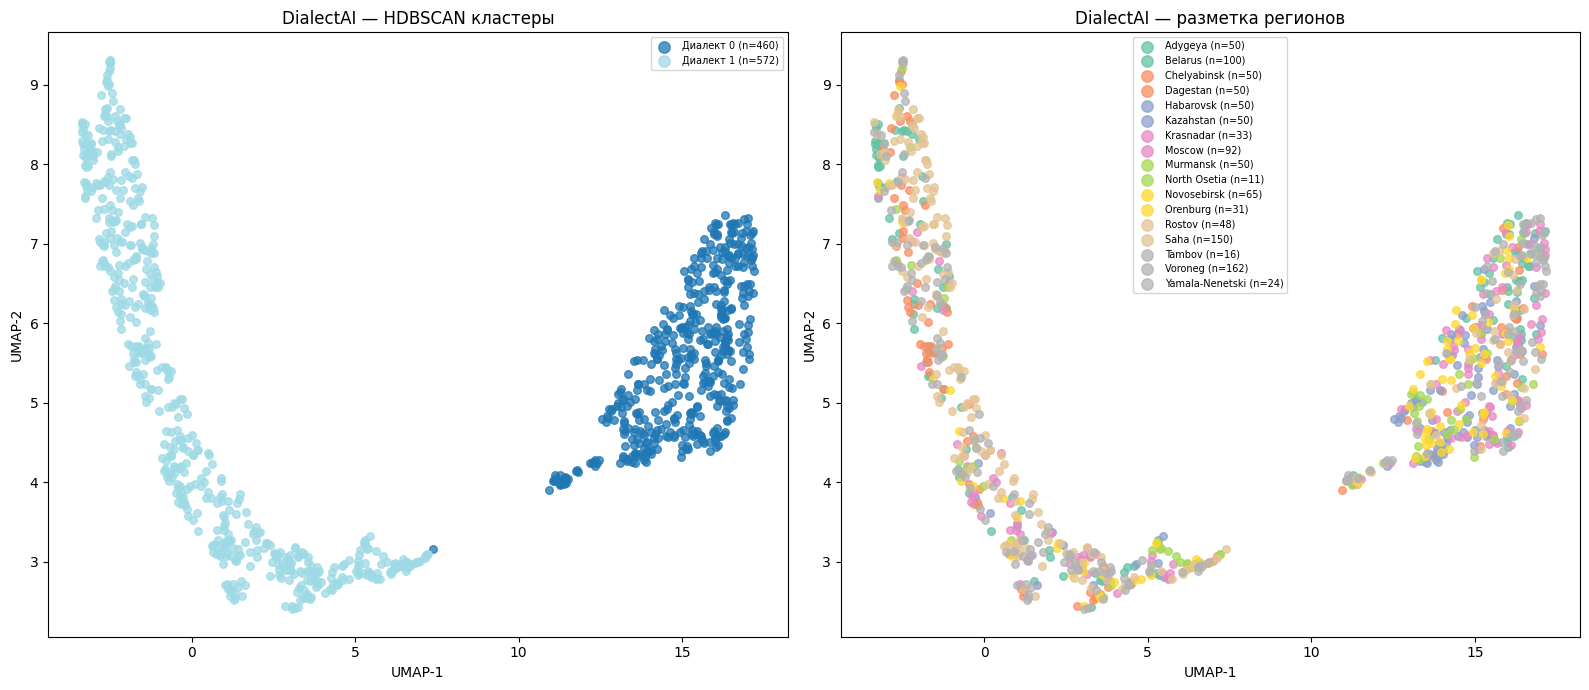

NameError: name 'job_labels' is not defined

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# 17. Кластеризация диалектов
# ─────────────────────────────────────────────────────────────────────────────

full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

log.info("Извлечение embeddings из всего датасета...")
all_emb, all_region_idx, all_job_idx = extract_all_embeddings(model, full_loader)

log.info("Кластеризация...")
cluster_labels, coords_2d = cluster_dialects(all_emb, OUT_DIR)

# Сохраняем результаты
df_results = pd.DataFrame({
    "path":    [s[0] for s in full_ds.samples],
    "region":  [s[1] for s in full_ds.samples],
    "job":     [s[2] for s in full_ds.samples],
    "cluster": cluster_labels,
    "umap_x":  coords_2d[:, 0],
    "umap_y":  coords_2d[:, 1],
})
df_results.to_csv(OUT_DIR / "dialect_clusters.csv", index=False)

print("\nРаспределение кластеров:")
print(
    df_results.groupby("cluster")
    .agg(count=("path", "count"),
         regions=("region", lambda x: ", ".join(sorted(x.unique()))))
    .to_string()
)

# Карта диалектов
plot_dialect_map(
    coords_2d, cluster_labels, all_region_idx,
    region_enc, title="DialectAI",
    save_path=OUT_DIR / "dialect_map.png",
)

In [85]:
# ─────────────────────────────────────────────────────────────────────────────
# 18. Inference
# ─────────────────────────────────────────────────────────────────────────────

# Инициализируем предиктор из текущей сессии
predictor = Predictor(model, region_enc, job_enc)

# Пример предсказания на первом файле датасета
sample_path = full_ds.samples[345][0]
print(f"Файл: {sample_path}")
print(f"Истинный регион: {full_ds.samples[0][1]}")
print(f"Истинная профессия: {full_ds.samples[0][2]}")

result = predictor.predict(sample_path)
print(f"\nПредсказанный регион:    {result['top_region']}")
print(f"Предсказанная профессия: {result['top_job']}")

# ── Загрузка из диска (production) ───────────────────────────────────────────
# region_enc_loaded, job_enc_loaded, meta = load_artifacts(OUT_DIR)
# model_loaded  = load_trained_model(OUT_DIR, meta)
# predictor2    = Predictor(model_loaded, region_enc_loaded, job_enc_loaded)
# result2       = predictor2.predict("path/to/audio.wav")

Файл: dataset\Kazahstan\кзс_актер.озвучки_046.wav
Истинный регион: Adygeya
Истинная профессия: video.mp4

📍 Регион:
   Kazahstan              ████████████████             0.599
   Novosebirsk            ████                         0.166
   Adygeya                ███                          0.141
   Orenburg               █                            0.036
   Moscow                                              0.026
   Murmansk                                            0.015
   Habarovsk                                           0.006
   Belarus                                             0.005
   Tambov                                              0.002
   Rostov                                              0.002
   Krasnadar                                           0.001
   North Osetia                                        0.001
   Chelyabinsk                                         0.000
   Dagestan                                            0.000
   Saha                       